In [1]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import optuna

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4941, 3)
(4941, 8)
(5150, 8)


In [4]:
# CatBoost
from catboost import CatBoostRegressor

# Avoiding any modification to original data sets since it uses column names and datatypes
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

X_train_cat = pd.DataFrame(X_train_cat, columns=feature_cols)
cat_features = X_train_cat.select_dtypes(include=["object", "category"]).columns.tolist()
#cat_features = ["high_t_evt"]
#Tuning CatBoost in Optuna using the same method as XGBoost
def objective_cat(trial):
  CatBoost = CatBoostRegressor(
      iterations = 100,
      learning_rate = trial.suggest_float("learning_rate",0.01,0.1,log=True),
      depth = trial.suggest_int("depth",2,8),
      loss_function = "RMSE",
      eval_metric = "RMSE",
      random_seed = 42,
      verbose=False,
      allow_writing_files=False,
      posterior_sampling=True,
      )

  CatBoost.fit(
      X_train_cat, y_train, eval_set=(X_val_cat, y_val),cat_features=cat_features, use_best_model=True)
  predictions_cat = CatBoost.predict(X_val_cat)
  RMSE_cat = root_mean_squared_error(y_val, predictions_cat)
  return RMSE_cat
optimization_cat= optuna.create_study(direction="minimize",sampler=optuna.samplers.TPESampler(seed=42)) #minimizing the above parameters
optimization_cat.optimize(objective_cat, n_trials=30) #keeping trails low for runtime and to prevent over-fitting noise

optimal_params_cat = optimization_cat.best_params
print("Optimal Parameters Cat:", optimal_params_cat)

#Running CatBoost with the optimal parameters
CatBoost = CatBoostRegressor(
    iterations = 100,
    **optimal_params_cat,
    loss_function = "RMSE",
    eval_metric = "RMSE",
    random_seed = 42,
    verbose=False,
    allow_writing_files=False
    )

CatBoost.fit(
    X_train_cat, y_train, eval_set=(X_val_cat, y_val),cat_features=cat_features, use_best_model=True)

# Calculating the multiplicative error
CatBoost_Prediction = CatBoost.predict(X_test_cat)
CatBoost_RMSE = root_mean_squared_error(y_test, CatBoost_Prediction)
CatBoost_Error = CatBoost_RMSE
print("CatBoost Error:", CatBoost_Error)

[I 2026-02-01 20:48:39,487] A new study created in memory with name: no-name-ee92d660-9079-40a5-bb83-be7336c7d075
[I 2026-02-01 20:48:39,968] Trial 0 finished with value: 18926.128971931947 and parameters: {'learning_rate': 0.023688639503640783, 'depth': 8}. Best is trial 0 with value: 18926.128971931947.
[I 2026-02-01 20:48:40,101] Trial 1 finished with value: 18747.046976615977 and parameters: {'learning_rate': 0.05395030966670229, 'depth': 6}. Best is trial 1 with value: 18747.046976615977.
[I 2026-02-01 20:48:40,183] Trial 2 finished with value: 19678.72541534464 and parameters: {'learning_rate': 0.014322493718230255, 'depth': 3}. Best is trial 1 with value: 18747.046976615977.
[I 2026-02-01 20:48:40,433] Trial 3 finished with value: 19195.760101561485 and parameters: {'learning_rate': 0.011430983876313222, 'depth': 8}. Best is trial 1 with value: 18747.046976615977.
[I 2026-02-01 20:48:40,569] Trial 4 finished with value: 18964.308414086212 and parameters: {'learning_rate': 0.0399

Optimal Parameters Cat: {'learning_rate': 0.09726306599736462, 'depth': 7}
CatBoost Error: 18011.181780918312


CatBoost Error: 18128.824858864158
Average Error per Record in seconds for Cat: 14217.550640147187
Sample0: True = 87165.00s, Predicted = 53754.47s, Error=33410.53s
Sample1: True = 53850.00s, Predicted = 61009.07s, Error=7159.07s
Sample2: True = 58680.00s, Predicted = 58512.22s, Error=167.78s
Sample3: True = 44400.00s, Predicted = 46012.97s, Error=1612.97s
Sample4: True = 51975.00s, Predicted = 56076.61s, Error=4101.61s
Sample5: True = 89700.00s, Predicted = 82185.11s, Error=7514.89s
Sample6: True = 84960.00s, Predicted = 59454.87s, Error=25505.13s
Sample7: True = 44625.00s, Predicted = 65892.76s, Error=21267.76s
Sample8: True = 41040.00s, Predicted = 54828.96s, Error=13788.96s
Sample9: True = 59085.00s, Predicted = 60768.80s, Error=1683.80s
Sample10: True = 32670.00s, Predicted = 57368.39s, Error=24698.39s
Sample11: True = 49545.00s, Predicted = 60735.08s, Error=11190.08s
Sample12: True = 51585.00s, Predicted = 51187.47s, Error=397.53s
Sample13: True = 93690.00s, Predicted = 77590.49s

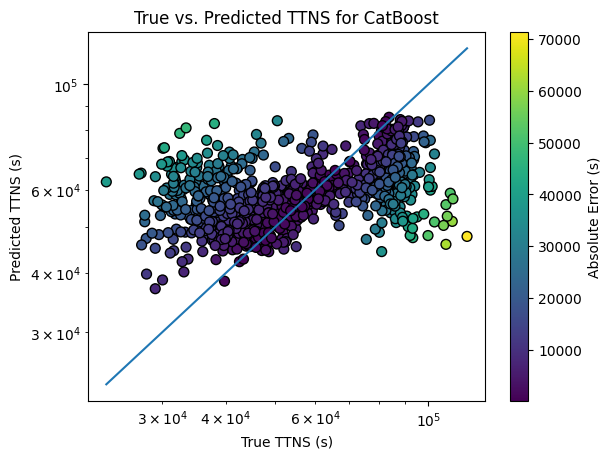

In [ ]:
#Calculating multiplicative error for CatBoost
CatBoost_Prediction = CatBoost.predict(X_test_cat)
CatBoost_RMSE = root_mean_squared_error(y_test, CatBoost_Prediction)
CatBoost_Error = CatBoost_RMSE
print("CatBoost Error:", CatBoost_Error)

y_test_secs = y_test
Cat_pred_secs = CatBoost_Prediction

absolute_error_secs_Cat = np.abs(Cat_pred_secs - y_test_secs)

#absoulte_error_cat = np.abs(10**CatBoost_Prediction - y_test)
MAE_seconds = np.mean(absolute_error_secs_Cat)
print("Average Error per Record in seconds for Cat:", MAE_seconds)


#Calculating true value, predicted, and average error in terms of seconds for each event
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, Cat_pred_secs, absolute_error_secs_Cat)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, Cat_pred_secs, c=absolute_error_secs_Cat, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for CatBoost")
plt.xscale('log')
plt.yscale('log')
plt.show()

Cat Boost Drivers: form_fac       2997.295413
tide_height    2630.470806
slip_size      2017.435230
high_t_evt     1517.396216
time_since     1513.145693
tide_deriv     1492.502304
dtype: float64


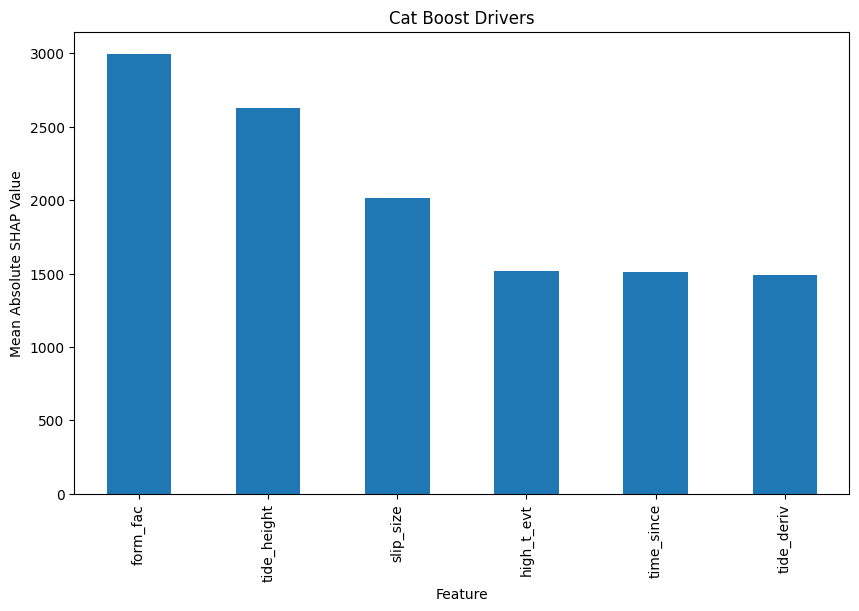

In [ ]:
# Driving parameters for Cat

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
explainer_cat = shap.TreeExplainer(CatBoost, X_shap, feature_perturbation="interventional")

shap_values_cat = explainer_cat.shap_values(X_shap)#Doing the tree analysis on Cat uisng training data

Cat_imp = pd.Series(np.abs(shap_values_cat).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)#Analysis of driving parameters in Cat

print("Cat Boost Drivers:", Cat_imp)

# Creating a bar graph showing the driving parameters for CatBoost


plt.figure(figsize=(10, 6))
Cat_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("Cat Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()